In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer

In [14]:
def give_cabin_letter(cabin):
  return cabin[0]

def give_title(name):
  name = name.lower()
  if 'mrs' in name:
    return 'mrs'
  elif 'mr' in name:
    return 'mr'
  elif 'miss' in name:
    return 'miss'
  elif 'master' in name:
    return 'master'
  else: return 'na'

In [15]:
dataset = pd.read_csv('/content/train.csv')

In [16]:
dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [17]:
dataset.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [18]:
dataset.Cabin.fillna('U', inplace = True)

/tmp/ipython-input-3388864552.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset.Cabin.fillna('U', inplace = True)


In [19]:
dataset.Cabin = dataset.Cabin.apply(give_cabin_letter)

In [20]:
dataset.Name = dataset.Name.apply(give_title)

In [21]:
dataset.Name.value_counts()

,count
Name,
mr,518
miss,180
mrs,129
master,40
na,24


In [22]:
dataset.drop('Ticket', axis = 1, inplace = True)

In [23]:
dataset['Family_count'] = dataset['Parch'] + dataset['SibSp']

In [24]:
dataset.drop(['Parch', 'SibSp'], axis = 1, inplace = True)

In [25]:
most_freq_embark = dataset.Embarked.mode()[0]
median_age = dataset.Age.median()

In [26]:
dataset.Age.fillna(median_age, inplace = True)
dataset.Embarked.fillna(most_freq_embark, inplace = True)

/tmp/ipython-input-311638319.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset.Age.fillna(median_age, inplace = True)
/tmp/ipython-input-311638319.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [27]:
dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,Fare,Cabin,Embarked,Family_count
0,1,0,3,mr,male,22.0,7.2500,U,S,1
1,2,1,1,mrs,female,38.0,71.2833,C,C,1
2,3,1,3,miss,female,26.0,7.9250,U,S,0
3,4,1,1,mrs,female,35.0,53.1000,C,S,1
4,5,0,3,mr,male,35.0,8.0500,U,S,0
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,na,male,27.0,13.0000,U,S,0
887,888,1,1,miss,female,19.0,30.0000,B,S,0
888,889,0,3,miss,female,28.0,23.4500,U,S,3
889,890,1,1,mr,male,26.0,30.0000,C,C,0


In [28]:
dataset.drop('PassengerId', axis = 1, inplace = True)

In [29]:
y = dataset.Survived

In [30]:
dataset.drop('Survived', axis = 1, inplace = True)

In [31]:
dataset

,Pclass,Name,Sex,Age,Fare,Cabin,Embarked,Family_count
0,3,mr,male,22.0,7.2500,U,S,1
1,1,mrs,female,38.0,71.2833,C,C,1
2,3,miss,female,26.0,7.9250,U,S,0
3,1,mrs,female,35.0,53.1000,C,S,1
4,3,mr,male,35.0,8.0500,U,S,0
...,...,...,...,...,...,...,...,...
886,2,na,male,27.0,13.0000,U,S,0
887,1,miss,female,19.0,30.0000,B,S,0
888,3,miss,female,28.0,23.4500,U,S,3
889,1,mr,male,26.0,30.0000,C,C,0


In [32]:
one_hot = ['Name','Sex','Embarked']
ordinal = ['Cabin']

In [33]:
ct = ColumnTransformer(transformers=[
    ('one_hot_encoding', OneHotEncoder(drop = 'if_binary'), one_hot),
    ('ordinal_encoding', OrdinalEncoder(), ordinal)
], remainder = 'passthrough')

In [34]:
encoded_array = ct.fit_transform(dataset)

In [35]:
raw_cols = ct.get_feature_names_out()
cols = [name.split('__')[-1] for name in raw_cols]

In [36]:
new_df = pd.DataFrame(encoded_array, columns=cols)

In [37]:
new_df

,Name_master,Name_miss,Name_mr,Name_mrs,Name_na,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Cabin,Pclass,Age,Fare,Family_count
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,8.0,3.0,22.0,7.2500,1.0
1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2.0,1.0,38.0,71.2833,1.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,8.0,3.0,26.0,7.9250,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,35.0,53.1000,1.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,8.0,3.0,35.0,8.0500,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,8.0,2.0,27.0,13.0000,0.0
887,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,19.0,30.0000,0.0
888,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,8.0,3.0,28.0,23.4500,3.0
889,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,2.0,1.0,26.0,30.0000,0.0


In [38]:
models = [
    ('logisticreg', LogisticRegression()),
    ('RandomForest', RandomForestClassifier()),
    ('DecisionTree', DecisionTreeClassifier()),
    ('xgbregressor', XGBClassifier()),
    ('GradientBoost', GradientBoostingClassifier(n_estimators=50, learning_rate = 0.08, random_state = 43))
]

In [39]:
results = []
kf = KFold(n_splits = 10, shuffle = True, random_state = 43)

for name, model in models:
  training_model = Pipeline(steps=[
      ('standard_scalar', StandardScaler()),
      (name, model)
  ])

  scores = cross_val_score(training_model, new_df, y, cv = kf)

  results.append({
      'Model_Name':name,
      'Mean_accuracy':scores.mean(),
      'std dev':scores.std()
  })

result_df = pd.DataFrame(results)

In [40]:
result_df.sort_values(by = 'Mean_accuracy', ascending=False)

,Model_Name,Mean_accuracy,std dev
4,GradientBoost,0.827216,0.034154
0,logisticreg,0.826080,0.029952
3,xgbregressor,0.808090,0.029424
1,RandomForest,0.806991,0.027153
2,DecisionTree,0.800250,0.030288


In [41]:
xtrain, xtest, ytrain, ytest = train_test_split(new_df, y, stratify = y, test_size = 0.2, random_state = 43)

In [42]:
model1 = RandomForestClassifier(n_estimators=100)
model2 = GradientBoostingClassifier(n_estimators=100, learning_rate = 0.08, random_state = 1)

In [43]:
model1.fit(xtrain, ytrain)
model2.fit(xtrain, ytrain)

GradientBoostingClassifier(learning_rate=0.08, random_state=1)

In [44]:
ypreds1 = model1.predict(xtest)
ypreds2 = model2.predict(xtest)

In [45]:
accuracy1 = accuracy_score(ypreds1, ytest)
accuracy2 = accuracy_score(ypreds2, ytest)

In [46]:
print(accuracy1)
print(accuracy2)

0.8044692737430168
0.8379888268156425


<Axes: >

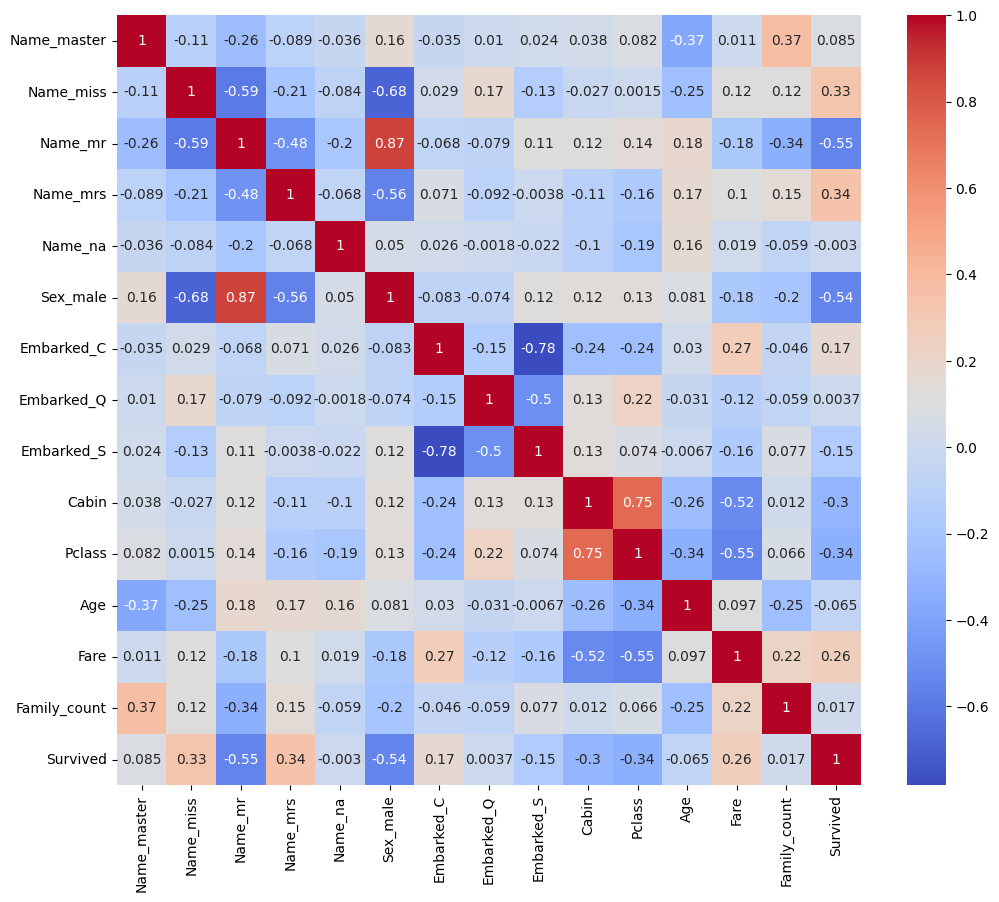

In [53]:
fig, ax = plt.subplots(figsize=(12,10))
sns.heatmap(new_df.corr(), cmap = 'coolwarm', cbar = True, annot = True)

In [79]:
final_model = GradientBoostingClassifier(n_estimators=100, learning_rate = 0.08, random_state = 43)
final_model.fit(new_df, y)

GradientBoostingClassifier(learning_rate=0.08, random_state=43)

In [54]:
test_dataset = pd.read_csv('/content/test.csv')

In [55]:
test_dataset

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [57]:
passengerID = test_dataset.PassengerId
test_dataset['family_count'] = test_dataset['Parch'] + test_dataset['SibSp']

In [59]:
test_dataset.drop(['PassengerId', 'Parch','SibSp','Ticket'], axis = 1, inplace = True)

In [60]:
test_dataset

,Pclass,Name,Sex,Age,Fare,Cabin,Embarked,family_count
0,3,"Kelly, Mr. James",male,34.5,7.8292,NaN,Q,0
1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,7.0000,NaN,S,1
2,2,"Myles, Mr. Thomas Francis",male,62.0,9.6875,NaN,Q,0
3,3,"Wirz, Mr. Albert",male,27.0,8.6625,NaN,S,0
4,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,12.2875,NaN,S,2
...,...,...,...,...,...,...,...,...
413,3,"Spector, Mr. Woolf",male,NaN,8.0500,NaN,S,0
414,1,"Oliva y Ocana, Dona. Fermina",female,39.0,108.9000,C105,C,0
415,3,"Saether, Mr. Simon Sivertsen",male,38.5,7.2500,NaN,S,0
416,3,"Ware, Mr. Frederick",male,NaN,8.0500,NaN,S,0


In [62]:
test_dataset.Cabin.fillna('U', inplace = True)

In [63]:
test_dataset.Cabin = test_dataset.Cabin.apply(give_cabin_letter)
test_dataset.Name = test_dataset.Name.apply(give_title)

In [65]:
median_age = test_dataset.Age.median()

In [67]:
test_dataset.Age.fillna(median_age, inplace=True)

/tmp/ipython-input-2361532883.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_dataset.Age.fillna(median_age, inplace=True)


In [71]:
test_dataset

,Pclass,Name,Sex,Age,Fare,Cabin,Embarked,Family_count
0,3,mr,male,34.5,7.8292,U,Q,0
1,3,mrs,female,47.0,7.0000,U,S,1
2,2,mr,male,62.0,9.6875,U,Q,0
3,3,mr,male,27.0,8.6625,U,S,0
4,3,mrs,female,22.0,12.2875,U,S,2
...,...,...,...,...,...,...,...,...
413,3,mr,male,27.0,8.0500,U,S,0
414,1,na,female,39.0,108.9000,C,C,0
415,3,mr,male,38.5,7.2500,U,S,0
416,3,mr,male,27.0,8.0500,U,S,0


In [70]:
test_dataset.rename(columns={'family_count':'Family_count'}, inplace = True)

In [72]:
encoded = ct.transform(test_dataset)

In [73]:
new_dataset = pd.DataFrame(encoded, columns=cols)

In [74]:
new_dataset

,Name_master,Name_miss,Name_mr,Name_mrs,Name_na,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Cabin,Pclass,Age,Fare,Family_count
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,8.0,3.0,34.5,7.8292,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,8.0,3.0,47.0,7.0000,1.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,8.0,2.0,62.0,9.6875,0.0
3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,8.0,3.0,27.0,8.6625,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,8.0,3.0,22.0,12.2875,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,8.0,3.0,27.0,8.0500,0.0
414,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,1.0,39.0,108.9000,0.0
415,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,8.0,3.0,38.5,7.2500,0.0
416,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,8.0,3.0,27.0,8.0500,0.0


In [82]:
new_dataset.isna().sum()

,0
Name_master,0
Name_miss,0
Name_mr,0
Name_mrs,0
Name_na,0
Sex_male,0
Embarked_C,0
Embarked_Q,0
Embarked_S,0
Cabin,0


In [83]:
median_fare = new_dataset.Fare.median()

In [84]:
new_dataset.Fare.fillna(median_fare, inplace = True)

/tmp/ipython-input-3306697806.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  new_dataset.Fare.fillna(median_fare, inplace = True)


In [85]:
preds = final_model.predict(new_dataset)

In [86]:
preds

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [88]:
submission = pd.DataFrame({
    "PassengerId":passengerID,
    "Survived": preds
})

In [90]:
submission

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [91]:
submission.to_csv('submission.csv', index = False)

In [92]:
old_submission = pd.read_csv('/content/submission.csv')

In [93]:
accuracy_score(old_submission.Survived, preds)

0.9569377990430622